#  Analisis Data Kebisingan Airfoil (Dataset 2)
##  Sains Data Rekayasa : Tugas Besar
**Teknik Fisika ITB | 2026**

---

### Deskripsi Dataset
Dataset **NASA Airfoil Self-Noise** berisi hasil pengukuran eksperimental aeroakustik dari berbagai profil airfoil NACA 0012 di terowongan angin. Data merepresentasikan hubungan antara parameter aliran udara terhadap tingkat tekanan bunyi (Sound Pressure Level).

| Kolom | Simbol | Satuan | Keterangan |
|---|---|---|---|
| `f` | Frekuensi | Hz | Frekuensi bunyi |
| `alpha` | Sudut Serang | derajat | Angle of attack |
| `c` | Chord Length | m | Panjang profil sayap |
| `U_infinity` | Kecepatan Aliran | m/s | Free-stream velocity |
| `delta` | Displacement Thickness | m | Tebal lapisan batas |
| `SSPL` | **Target** | dB | Scaled Sound Pressure Level |

**Sumber:** [UCI ML Repository — Airfoil Self-Noise](https://archive.ics.uci.edu/ml/datasets/Airfoil+Self-Noise) / Kaggle

### Fungsi ML yang Digunakan
- **Fungsi-1 → Regression**: Prediksi SSPL dari 5 variabel fisis (instan)
- **Fungsi-2 → Forecasting**: Peramalan SSPL berdasarkan urutan historis (sliding window)

### Metode yang Dibandingkan
- **CNN (1D-Convolutional Neural Network)**
- **RNN (SimpleRNN / LSTM)**

---
##  Bagian 0 — Import Library
### sebenarnya dilakukan hanya untuk mempermudah dan tidak perlu melakukan pengulangan dalam pemanggilan library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import joblib
import warnings
warnings.filterwarnings('ignore') #ini kaga wajib si

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# Pengaturan tampilan grafik
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'lines.linewidth': 1.5,
    'axes.grid': True,
    'grid.alpha': 0.3
})

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f'TensorFlow : {tf.__version__}')
print(f'NumPy      : {np.__version__}')
print(f'Pandas     : {pd.__version__}')
print(' Semua library berhasil diimport.')

TensorFlow : 2.21.0
NumPy      : 2.3.3
Pandas     : 3.0.2
 Semua library berhasil diimport.


---
##  Bagian 1 — Load & Eksplorasi Data

In [5]:
# ── Load CSV ──────────────────────────────────────────────────────────────────
df = pd.read_csv('AirfoilSelfNoise.csv')

print(f'Ukuran dataset : {df.shape}  ({df.shape[0]} sampel, {df.shape[1]} kolom)')
print(f'Kolom          : {df.columns.tolist()}')
print(f'Missing values : {df.isnull().sum().sum()} (total)')
display(df.head(5))

Ukuran dataset : (1503, 6)  (1503 sampel, 6 kolom)
Kolom          : ['f', 'alpha', 'c', 'U_infinity', 'delta', 'SSPL']
Missing values : 0 (total)


,f,alpha,c,U_infinity,delta,SSPL
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461


In [6]:
# ── Statistik deskriptif ──────────────────────────────────────────────────────
display(df.describe().round(4))

,f,alpha,c,U_infinity,delta,SSPL
count,1503.0000,1503.0000,1503.0000,1503.0000,1503.0000,1503.0000
mean,2886.3806,6.7823,0.1365,50.8607,0.0111,124.8359
std,3152.5731,5.9181,0.0935,15.5728,0.0132,6.8987
min,200.0000,0.0000,0.0254,31.7000,0.0004,103.3800
25%,800.0000,2.0000,0.0508,39.6000,0.0025,120.1910
50%,1600.0000,5.4000,0.1016,39.6000,0.0050,125.7210
75%,4000.0000,9.9000,0.2286,71.3000,0.0156,129.9955
max,20000.0000,22.2000,0.3048,71.3000,0.0584,140.9870


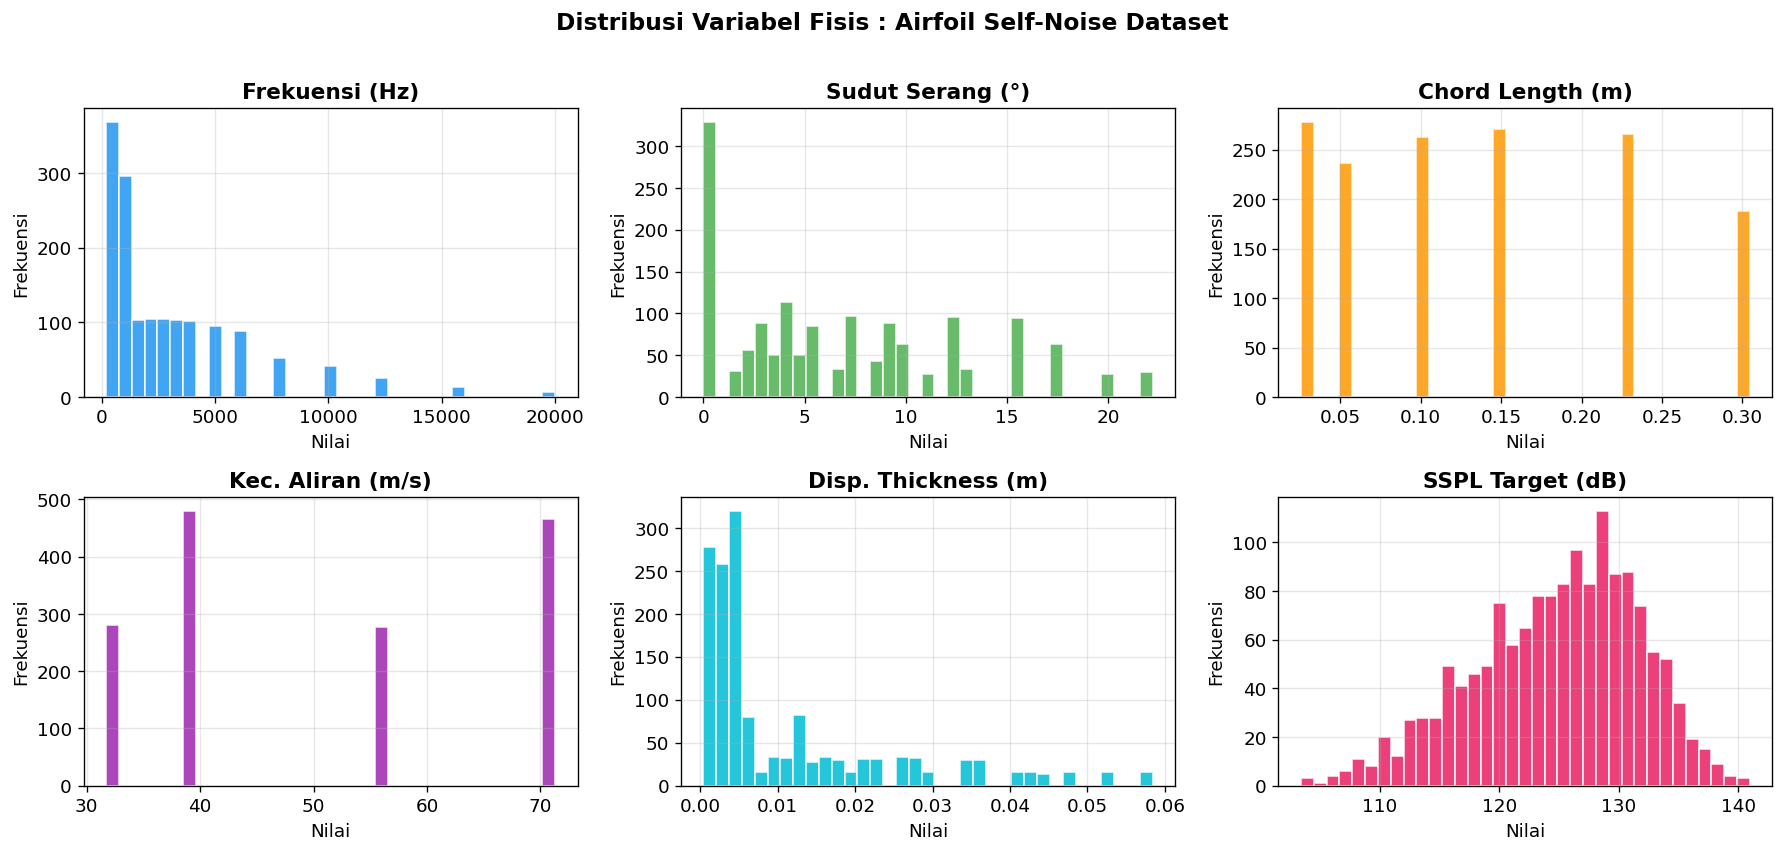

In [37]:
# ── Distribusi tiap variabel fisis ───────────────────────────────────────────
cols   = df.columns.tolist()
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#00BCD4', '#E91E63']
labels = [
    'Frekuensi (Hz)', 'Sudut Serang (°)', 'Chord Length (m)',
    'Kec. Aliran (m/s)', 'Disp. Thickness (m)', 'SSPL Target (dB)'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.flatten()

for ax, col, color, label in zip(axes, cols, colors, labels):
    ax.hist(df[col], bins=35, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Nilai')
    ax.set_ylabel('Frekuensi')

plt.suptitle('Distribusi Variabel Fisis : Airfoil Self-Noise Dataset',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

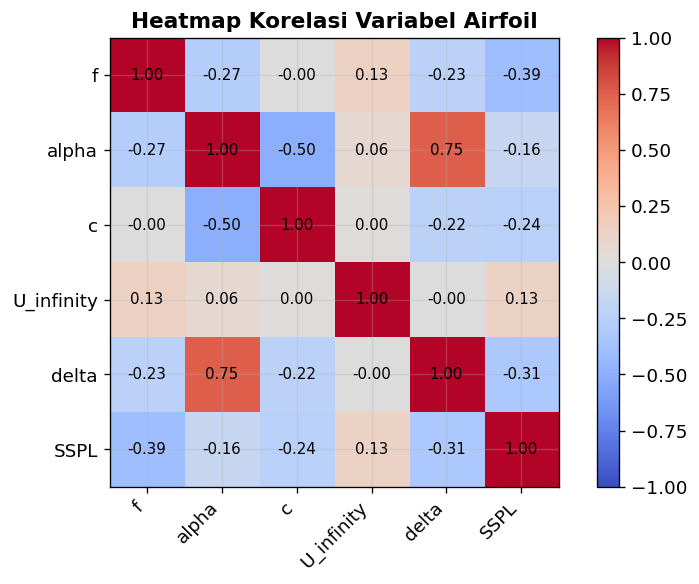

In [38]:
# ── Korelasi antar variabel ───────────────────────────────────────────────────
import matplotlib.cm as cm

corr = df.corr()
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
ax.set_title('Heatmap Korelasi Variabel Airfoil', fontweight='bold')
plt.tight_layout()
plt.show()

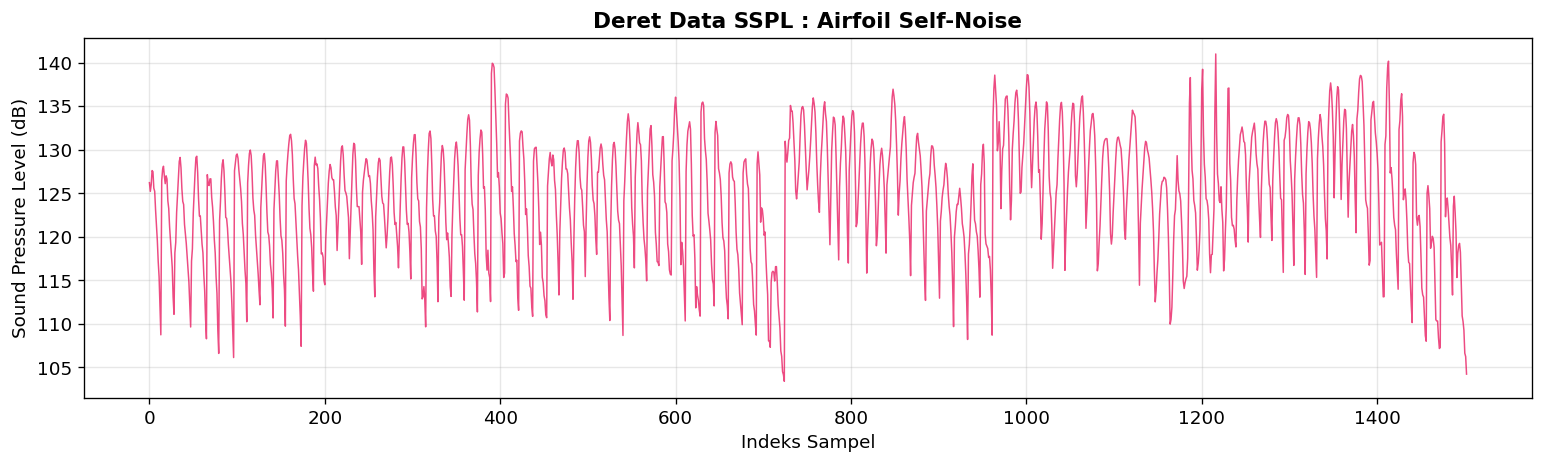

In [39]:
# ── Plot SSPL sebagai deret data (representasi tren) ─────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df['SSPL'].values, color='#E91E63', alpha=0.8, linewidth=0.9)
ax.set_title('Deret Data SSPL : Airfoil Self-Noise', fontweight='bold')
ax.set_xlabel('Indeks Sampel')
ax.set_ylabel('Sound Pressure Level (dB)')
plt.tight_layout()
plt.show()

---
##  Bagian 2 — Preprocessing Data

### Strategi Preprocessing
| Aspek | Keputusan |
|---|---|
| Normalisasi | MinMaxScaler → [0, 1] |
| Split | 80% Train / 20% Test (berurutan, tanpa shuffle) |
| Input Fungsi-1 | `(samples, 1, 5)` — 5 fitur fisis, timestep=1 |
| Input Fungsi-2 | `(samples, 10, 1)` — sliding window 10 langkah pada SSPL |

In [40]:
# ══════════════════════════════════════════════════════════
#  FUNGSI-1: REGRESSION — 5 fitur fisis → SSPL instan
# ══════════════════════════════════════════════════════════
scaler_X_reg = MinMaxScaler()
scaler_y_reg = MinMaxScaler()

X_reg = df.iloc[:, 0:5].values          # f, alpha, c, U_infinity, delta
y_reg = df['SSPL'].values.reshape(-1, 1)

X_reg_scaled = scaler_X_reg.fit_transform(X_reg)
y_reg_scaled = scaler_y_reg.fit_transform(y_reg)

# Reshape ke (samples, timesteps=1, features=5)
X_reg_dl = X_reg_scaled.reshape(X_reg_scaled.shape[0], 1, 5)

split_reg = int(len(X_reg_dl) * 0.8)
X_train_reg, X_test_reg = X_reg_dl[:split_reg], X_reg_dl[split_reg:]
y_train_reg, y_test_reg = y_reg_scaled[:split_reg], y_reg_scaled[split_reg:]

print('── Fungsi-1 (Regression) ──────────────────────────────')
print(f'  X_train : {X_train_reg.shape}  |  y_train : {y_train_reg.shape}')
print(f'  X_test  : {X_test_reg.shape}   |  y_test  : {y_test_reg.shape}')

── Fungsi-1 (Regression) ──────────────────────────────
  X_train : (1202, 1, 5)  |  y_train : (1202, 1)
  X_test  : (301, 1, 5)   |  y_test  : (301, 1)


In [41]:
# ══════════════════════════════════════════════════════════
#  FUNGSI-2: FORECASTING — sliding window pada SSPL
# ══════════════════════════════════════════════════════════
# Catatan: dataset Airfoil bukan time-series asli (tidak ada timestamp),
# namun urutan indeks digunakan sebagai representasi sekuensial tren kebisingan.

scaler_fore = MinMaxScaler()
y_fore_all  = scaler_fore.fit_transform(df['SSPL'].values.reshape(-1, 1))

TIMESTEPS = 10

def create_sliding_window(data, timesteps):
    """Membuat pasangan (X_sekuens, y_target) dari urutan data."""
    X, y = [], []
    for i in range(len(data) - timesteps):
        X.append(data[i : i + timesteps])
        y.append(data[i + timesteps])
    return np.array(X), np.array(y)

X_fore, y_fore = create_sliding_window(y_fore_all, TIMESTEPS)
# X_fore shape: (samples, 10, 1)

split_fore = int(len(X_fore) * 0.8)
X_train_fore, X_test_fore = X_fore[:split_fore], X_fore[split_fore:]
y_train_fore, y_test_fore = y_fore[:split_fore], y_fore[split_fore:]

print('── Fungsi-2 (Forecasting) ─────────────────────────────')
print(f'  X_train : {X_train_fore.shape}  |  y_train : {y_train_fore.shape}')
print(f'  X_test  : {X_test_fore.shape}   |  y_test  : {y_test_fore.shape}')
print(f'  Timesteps (look-back window) = {TIMESTEPS}')

── Fungsi-2 (Forecasting) ─────────────────────────────
  X_train : (1194, 10, 1)  |  y_train : (1194, 1)
  X_test  : (299, 10, 1)   |  y_test  : (299, 1)
  Timesteps (look-back window) = 10


---
##  Bagian 3 — Arsitektur Model

| Model | Fungsi | Input Shape | Keterangan |
|---|---|---|---|
| **1D-CNN** | Regression | (1, 5) | Conv1D kernel=1, korelasi antar 5 fitur fisis |
| **SimpleRNN** | Regression | (1, 5) | RNN dasar untuk regresi sesaat |
| **1D-CNN** | Forecasting | (10, 1) | Conv1D kernel=3 + MaxPooling, pola lokal SSPL |
| **LSTM** | Forecasting | (10, 1) | Long Short-Term Memory, pola jangka panjang |

In [42]:
def build_cnn_regression(input_shape=(1, 5)):
    """
    1D-CNN untuk regresi instan — 5 fitur fisis → SSPL.
    Conv1D kernel_size=1 mengekstrak korelasi non-linear tiap fitur.
    """
    model = models.Sequential([
        layers.Conv1D(filters=32, kernel_size=1, activation='relu', input_shape=input_shape),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='linear')
    ], name='CNN_Regression')
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


def build_rnn_regression(input_shape=(1, 5)):
    """
    SimpleRNN untuk regresi instan — sederhana dan cepat.
    """
    model = models.Sequential([
        layers.SimpleRNN(units=64, activation='tanh', input_shape=input_shape),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='linear')
    ], name='SimpleRNN_Regression')
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


def build_cnn_forecasting(input_shape=(10, 1)):
    """
    1D-CNN untuk forecasting deret SSPL.
    padding='same' menjaga dimensi agar MaxPooling tidak error.
    """
    model = models.Sequential([
        layers.Conv1D(filters=64, kernel_size=3, activation='relu',
                      padding='same', input_shape=input_shape),
        layers.MaxPooling1D(pool_size=2),
        layers.Flatten(),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='linear')
    ], name='CNN_Forecasting')
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


def build_lstm_forecasting(input_shape=(10, 1)):
    """
    LSTM untuk forecasting — menangkap ketergantungan jangka panjang.
    Dropout 0.2 sebagai regularisasi.
    """
    model = models.Sequential([
        layers.LSTM(units=64, activation='tanh',
                    return_sequences=False, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='linear')
    ], name='LSTM_Forecasting')
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


# Tampilkan ringkasan arsitektur semua model
for builder, shape in [
    (build_cnn_regression,  (1, 5)),
    (build_rnn_regression,  (1, 5)),
    (build_cnn_forecasting, (TIMESTEPS, 1)),
    (build_lstm_forecasting,(TIMESTEPS, 1))
]:
    m = builder(shape)
    print(f'\n{"="*50}')
    m.summary()

Model: "CNN_Regression"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_8 (Conv1D)               │ (None, 1, 32)          │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,417 (17.25 KB)

 Trainable params: 4,417 (17.25 KB)

 Non-trainable params: 0 (0.00 B)

...

Model: "LSTM_Forecasting"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

---
##  Bagian 4 — Training Model 🏋️🏋️🏋️🏋️

In [ ]:
# ── Helper: plot loss history ─────────────────────────────────────────────────
def plot_loss_history(history, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.plot(history.history['loss'],     label='Train Loss', color='#1565C0', linewidth=2)
    ax.plot(history.history['val_loss'], label='Val Loss',   color='#E65100',
            linewidth=2, linestyle='--')
    ax.set_title(f'Loss History : {title}', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    return ax


# Konfigurasi training
EPOCHS     = 100
BATCH_SIZE = 32
VAL_SPLIT  = 0.1

# EarlyStopping mencegah overfitting
early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=10,
    restore_best_weights=True, verbose=0
)

print('Konfigurasi Training:')
print(f'  Max Epochs = {EPOCHS} (EarlyStopping patience=10)')
print(f'  Batch Size = {BATCH_SIZE}')
print(f'  Val Split  = {VAL_SPLIT*100:.0f}%')

Konfigurasi Training:
  Max Epochs = 100 (EarlyStopping patience=10)
  Batch Size = 32
  Val Split  = 10%


  FUNGSI-1 — REGRESSION (5 fitur → SSPL)
[CNN Regression]    Selesai 14.53s | Epoch: 63
[SimpleRNN Regres.] Selesai 4.94s | Epoch: 10


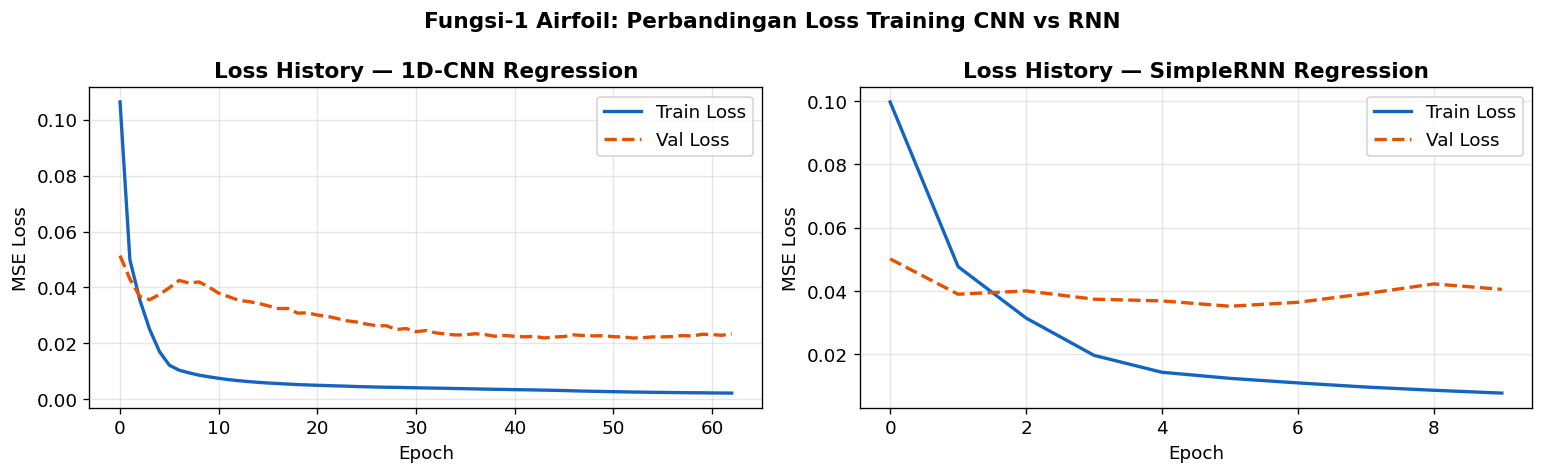

In [28]:
# ══════════════════════════════════════════════════════════
#  TRAINING — FUNGSI-1: REGRESSION
# ══════════════════════════════════════════════════════════
print('=' * 55)
print('  FUNGSI-1 — REGRESSION (5 fitur → SSPL)')
print('=' * 55)

model_cnn_reg = build_cnn_regression((1, 5))
t0 = time.time()
history_cnn_reg = model_cnn_reg.fit(
    X_train_reg, y_train_reg,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    callbacks=[early_stop], verbose=0
)
time_cnn_reg = time.time() - t0
print(f'[CNN Regression]    Selesai {time_cnn_reg:.2f}s | '
      f'Epoch: {len(history_cnn_reg.history["loss"])}')

model_rnn_reg = build_rnn_regression((1, 5))
t0 = time.time()
history_rnn_reg = model_rnn_reg.fit(
    X_train_reg, y_train_reg,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    callbacks=[early_stop], verbose=0
)
time_rnn_reg = time.time() - t0
print(f'[SimpleRNN Regres.] Selesai {time_rnn_reg:.2f}s | '
      f'Epoch: {len(history_rnn_reg.history["loss"])}')

# Plot loss berdampingan
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_loss_history(history_cnn_reg, '1D-CNN Regression', axes[0])
plot_loss_history(history_rnn_reg, 'SimpleRNN Regression', axes[1])
plt.suptitle('Fungsi-1 Airfoil: Perbandingan Loss Training CNN vs RNN',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

  FUNGSI-2 — FORECASTING (Sliding Window SSPL)
[CNN Forecasting]   Selesai 10.50s | Epoch: 42
[LSTM Forecasting]  Selesai 5.34s | Epoch: 10


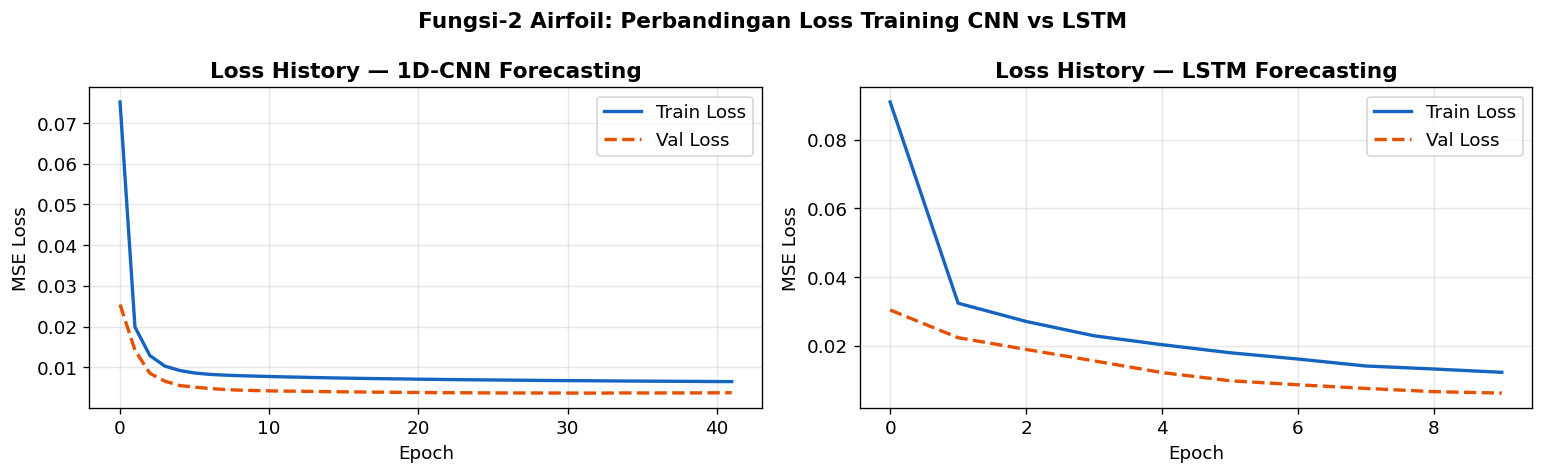

In [29]:
# ══════════════════════════════════════════════════════════
#  TRAINING — FUNGSI-2: FORECASTING
# ══════════════════════════════════════════════════════════
print('=' * 55)
print('  FUNGSI-2 — FORECASTING (Sliding Window SSPL)')
print('=' * 55)

model_cnn_fore = build_cnn_forecasting((TIMESTEPS, 1))
t0 = time.time()
history_cnn_fore = model_cnn_fore.fit(
    X_train_fore, y_train_fore,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    callbacks=[early_stop], verbose=0
)
time_cnn_fore = time.time() - t0
print(f'[CNN Forecasting]   Selesai {time_cnn_fore:.2f}s | '
      f'Epoch: {len(history_cnn_fore.history["loss"])}')

model_lstm_fore = build_lstm_forecasting((TIMESTEPS, 1))
t0 = time.time()
history_lstm_fore = model_lstm_fore.fit(
    X_train_fore, y_train_fore,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    callbacks=[early_stop], verbose=0
)
time_lstm_fore = time.time() - t0
print(f'[LSTM Forecasting]  Selesai {time_lstm_fore:.2f}s | '
      f'Epoch: {len(history_lstm_fore.history["loss"])}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_loss_history(history_cnn_fore, '1D-CNN Forecasting', axes[0])
plot_loss_history(history_lstm_fore, 'LSTM Forecasting', axes[1])
plt.suptitle('Fungsi-2 Airfoil: Perbandingan Loss Training CNN vs LSTM',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
##  Bagian 5 — Evaluasi & Analisis Hasil

In [30]:
def evaluate_and_plot(model, X_test, y_test, scaler, title, n_plot=100):
    """
    Evaluasi lengkap: MSE, RMSE, MAE, R²
    + Plot prediksi vs aktual & scatter plot
    """
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_true = scaler.inverse_transform(y_test.reshape(-1, 1))
    y_pred = scaler.inverse_transform(y_pred_scaled)

    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    # Subplot kiri: time-plot prediksi vs aktual
    axes[0].plot(y_true[:n_plot], label='SSPL Aktual (dB)',
                 color='#1565C0', alpha=0.85)
    axes[0].plot(y_pred[:n_plot], label='Prediksi Model',
                 color='#E53935', linestyle='--', alpha=0.9)
    axes[0].set_title(f'{title}\nPrediksi vs Aktual ({n_plot} sampel)', fontweight='bold')
    axes[0].set_xlabel('Indeks Sampel Pengujian')
    axes[0].set_ylabel('Sound Pressure Level (dB)')
    axes[0].legend()

    # Subplot kanan: scatter plot
    axes[1].scatter(y_true, y_pred, alpha=0.35, s=10, color='#5C6BC0')
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    axes[1].plot([lo, hi], [lo, hi], 'r--', linewidth=2, label='Ideal (y=x)')
    axes[1].set_title(f'Scatter: Prediksi vs Aktual\nR² = {r2:.4f}', fontweight='bold')
    axes[1].set_xlabel('Nilai Aktual (dB)')
    axes[1].set_ylabel('Nilai Prediksi (dB)')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    print(f'  MSE  = {mse:>10.4f}')
    print(f'  RMSE = {rmse:>10.4f}')
    print(f'  MAE  = {mae:>10.4f}')
    print(f'  R²   = {r2:>10.4f}')
    print()

    return {'Model': title, 'MSE': round(mse,4), 'RMSE': round(rmse,4),
            'MAE': round(mae,4), 'R²': round(r2,4)}

print(' Fungsi evaluasi siap.')

 Fungsi evaluasi siap.


  EVALUASI FUNGSI-1 — REGRESSION

── 1D-CNN Regression ──


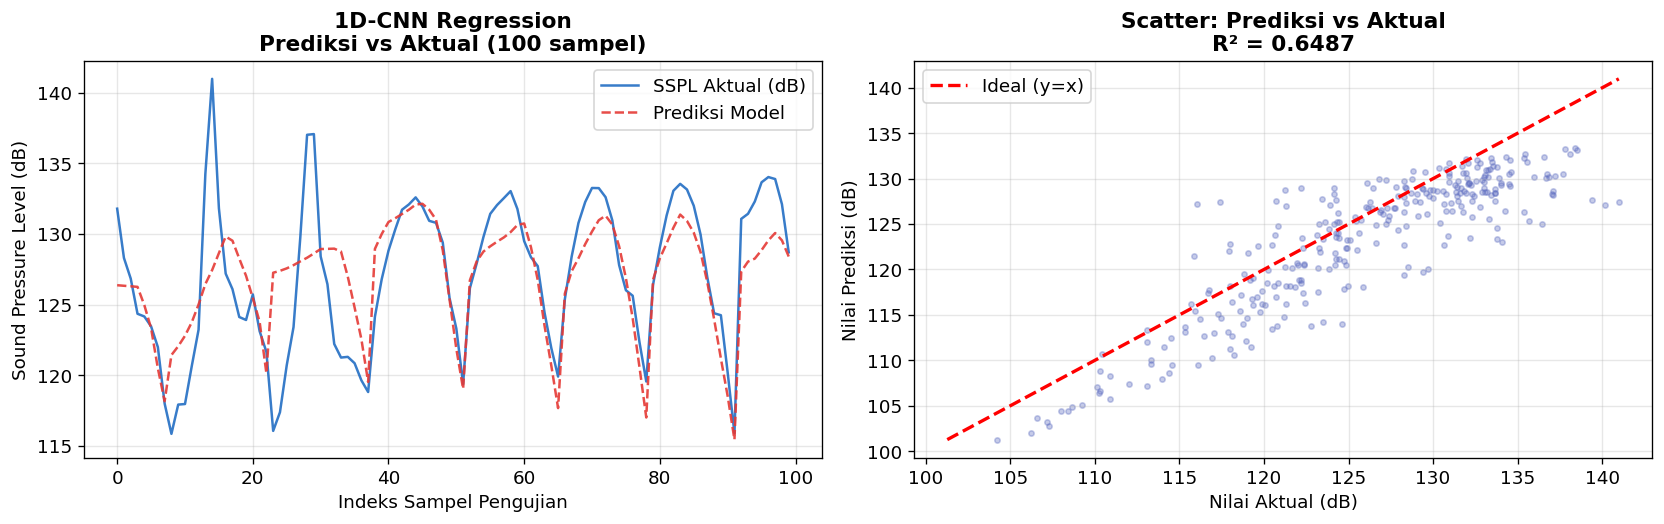

  MSE  =    19.8401
  RMSE =     4.4542
  MAE  =     3.5582
  R²   =     0.6487

── SimpleRNN Regression ──


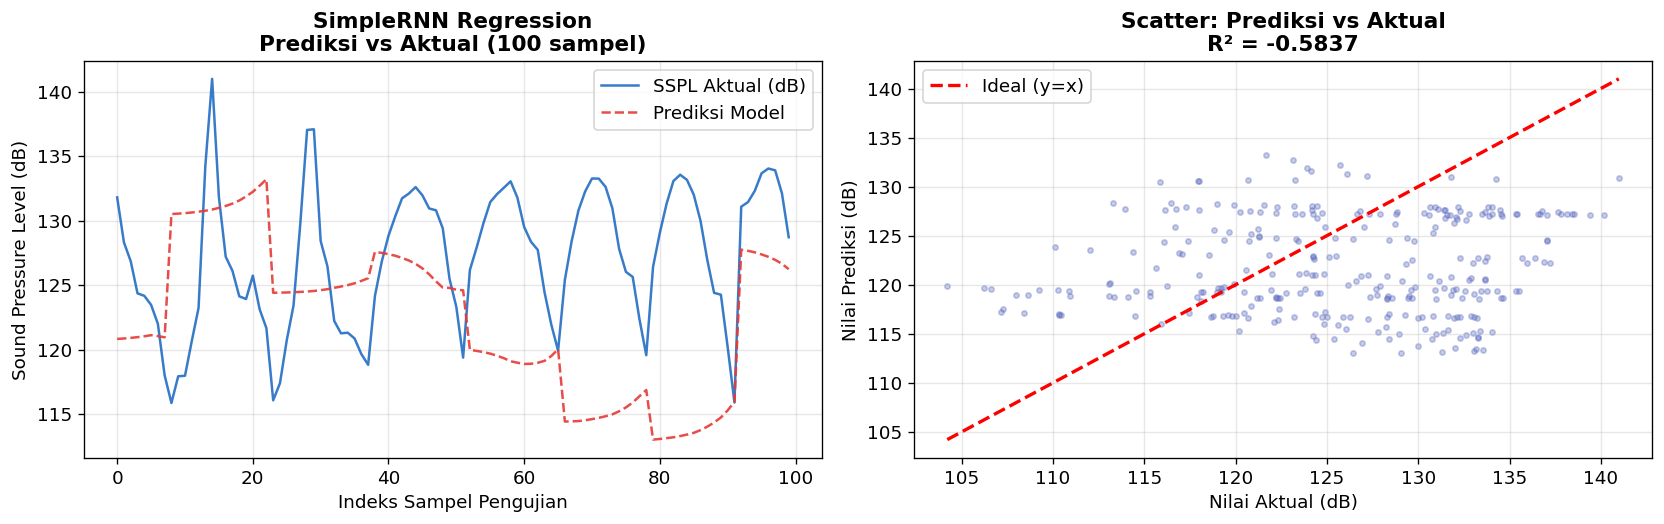

  MSE  =    89.4551
  RMSE =     9.4581
  MAE  =     8.0518
  R²   =    -0.5837



In [31]:
# ── EVALUASI FUNGSI-1: REGRESSION ────────────────────────────────────────────
print('=' * 55)
print('  EVALUASI FUNGSI-1 — REGRESSION')
print('=' * 55)

print('\n── 1D-CNN Regression ──')
res_cnn_reg = evaluate_and_plot(
    model_cnn_reg, X_test_reg, y_test_reg, scaler_y_reg, '1D-CNN Regression')

print('── SimpleRNN Regression ──')
res_rnn_reg = evaluate_and_plot(
    model_rnn_reg, X_test_reg, y_test_reg, scaler_y_reg, 'SimpleRNN Regression')

  EVALUASI FUNGSI-2 — FORECASTING

── 1D-CNN Forecasting ──


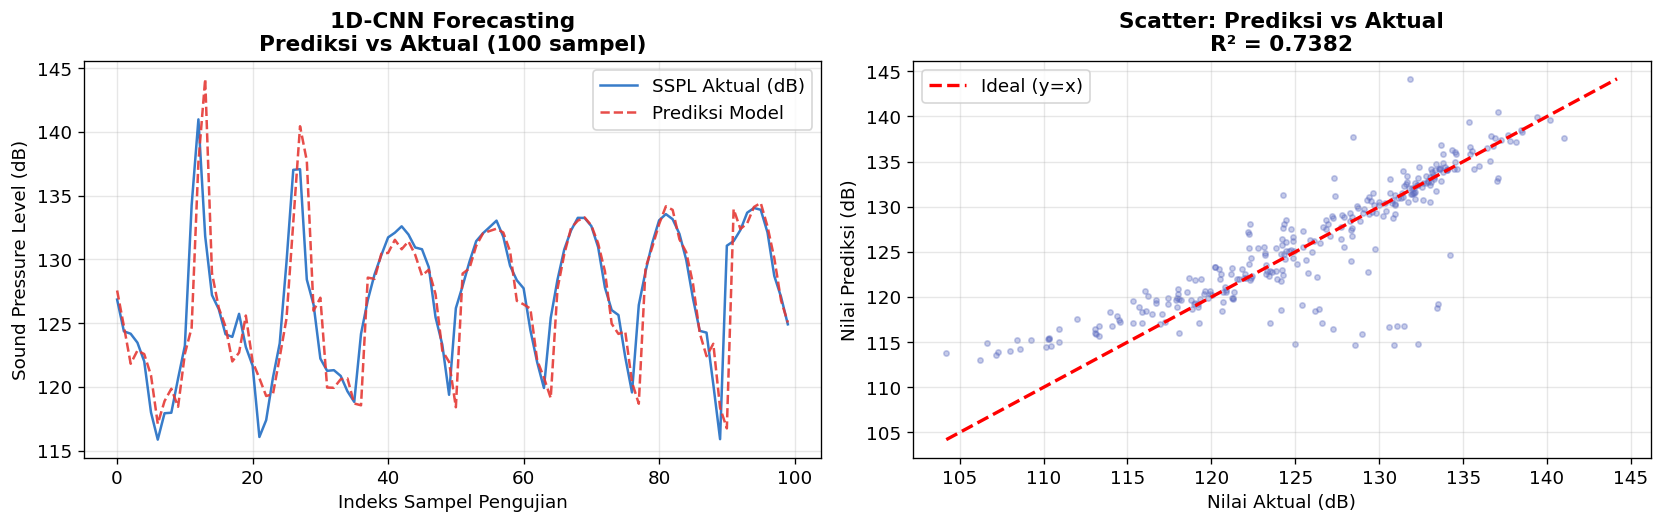

  MSE  =    14.8463
  RMSE =     3.8531
  MAE  =     2.3260
  R²   =     0.7382

── LSTM Forecasting ──


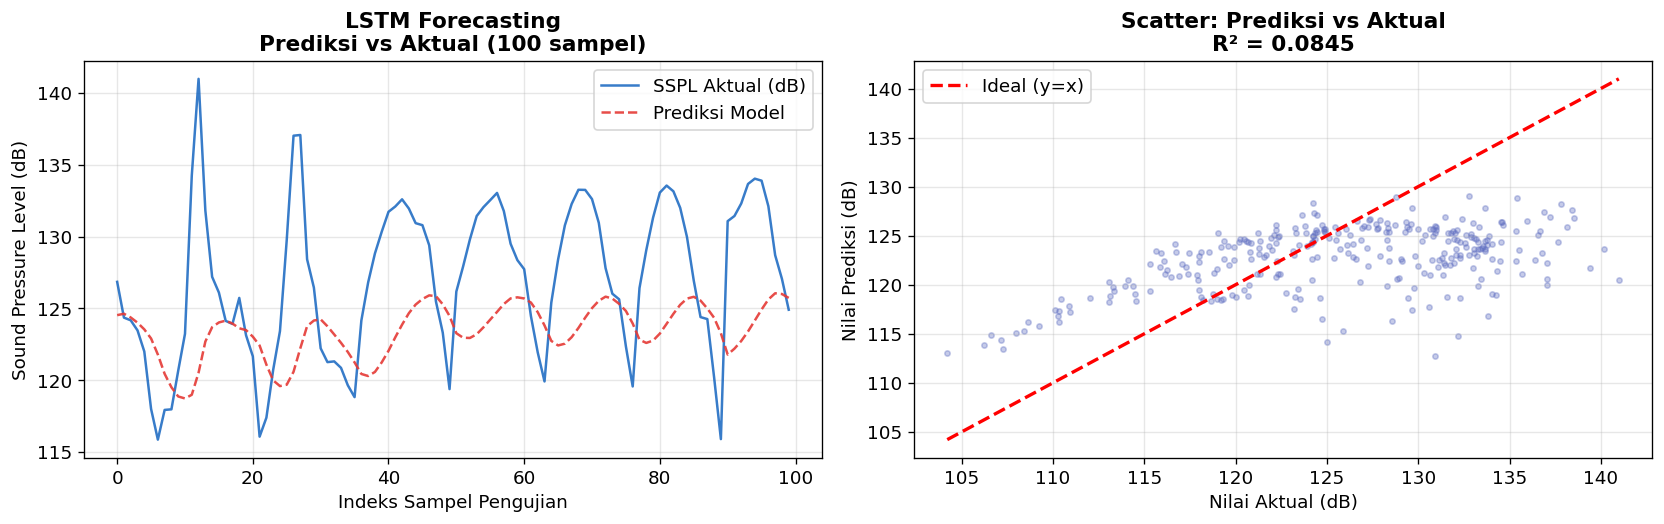

  MSE  =    51.9257
  RMSE =     7.2059
  MAE  =     5.8710
  R²   =     0.0845



In [32]:
# ── EVALUASI FUNGSI-2: FORECASTING ───────────────────────────────────────────
print('=' * 55)
print('  EVALUASI FUNGSI-2 — FORECASTING')
print('=' * 55)

print('\n── 1D-CNN Forecasting ──')
res_cnn_fore = evaluate_and_plot(
    model_cnn_fore, X_test_fore, y_test_fore, scaler_fore, '1D-CNN Forecasting')

print('── LSTM Forecasting ──')
res_lstm_fore = evaluate_and_plot(
    model_lstm_fore, X_test_fore, y_test_fore, scaler_fore, 'LSTM Forecasting')

---
##  Bagian 6 — Tabel Komparasi Performa (Multimetrik)

In [33]:
# ── Tabel komparasi ───────────────────────────────────────────────────────────
results = [
    {**res_cnn_reg,  'Fungsi': 'Regression',  'Waktu (s)': round(time_cnn_reg,  2)},
    {**res_rnn_reg,  'Fungsi': 'Regression',  'Waktu (s)': round(time_rnn_reg,  2)},
    {**res_cnn_fore, 'Fungsi': 'Forecasting', 'Waktu (s)': round(time_cnn_fore, 2)},
    {**res_lstm_fore,'Fungsi': 'Forecasting', 'Waktu (s)': round(time_lstm_fore,2)},
]

df_results = pd.DataFrame(results)[['Fungsi','Model','MSE','RMSE','MAE','R²','Waktu (s)']]

print('\n====== TABEL KOMPARASI PERFORMA — AIRFOIL DATASET ======')
display(df_results.style
    .background_gradient(subset=['R²'],              cmap='RdYlGn')
    .background_gradient(subset=['MSE','RMSE','MAE'],cmap='RdYlGn_r')
    .set_caption('Komparasi CNN vs RNN — Airfoil Self-Noise Dataset')
    .format({'MSE':'{:.4f}','RMSE':'{:.4f}','MAE':'{:.4f}','R²':'{:.4f}'})
)


====== TABEL KOMPARASI PERFORMA — AIRFOIL DATASET ======


,Fungsi,Model,MSE,RMSE,MAE,R²,Waktu (s)
0,Regression,1D-CNN Regression,19.8401,4.4542,3.5582,0.6487,14.530000
1,Regression,SimpleRNN Regression,89.4551,9.4581,8.0518,-0.5837,4.940000
2,Forecasting,1D-CNN Forecasting,14.8463,3.8531,2.3260,0.7382,10.500000
3,Forecasting,LSTM Forecasting,51.9257,7.2059,5.8710,0.0845,5.340000


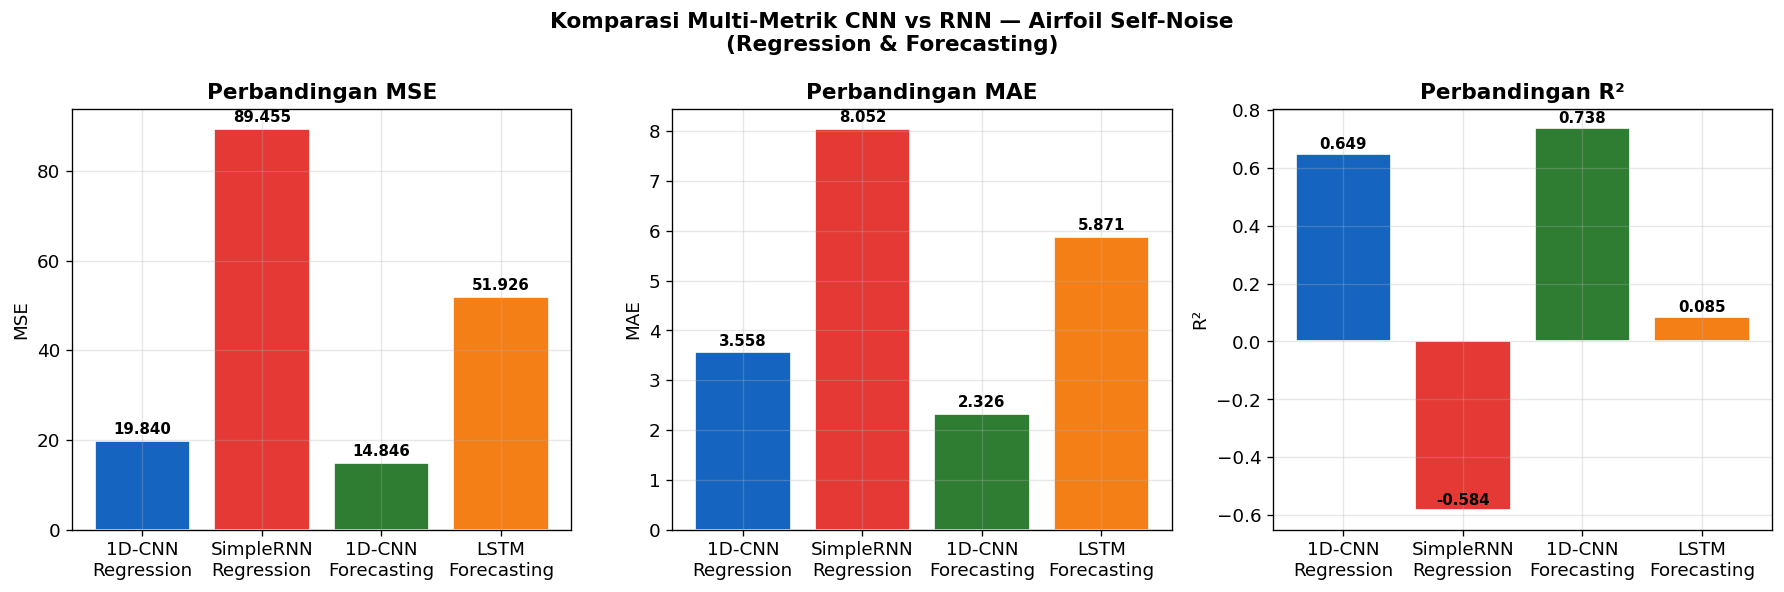

In [ ]:
# ── Bar chart multimetrik ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors_bar = ['#1565C0', '#E53935', '#2E7D32', '#F57F17']
labels_bar = [r['Model'].replace(' ', '\n') for r in results]

for ax, metric in zip(axes, ['MSE', 'MAE', 'R²']):
    vals = [r[metric] for r in results]
    bars = ax.bar(labels_bar, vals, color=colors_bar, edgecolor='white')
    ax.set_title(f'Perbandingan {metric}', fontweight='bold')
    ax.set_ylabel(metric)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.01,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')

plt.suptitle('Komparasi Multi-Metrik CNN vs RNN : Airfoil Self-Noise\n(Regression & Forecasting)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

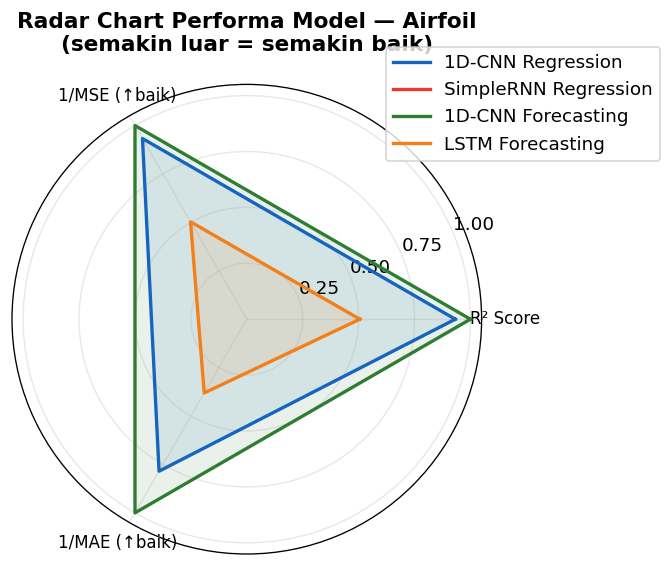

In [35]:
# ── Radar chart performa ──────────────────────────────────────────────────────
def normalize_metrics(results_list):
    out = []
    for m in ['R²', 'MSE', 'MAE']:
        vals = np.array([r[m] for r in results_list], dtype=float)
        if m == 'R²':
            n = (vals - vals.min()) / (vals.max() - vals.min() + 1e-9)
        else:
            n = 1 - (vals - vals.min()) / (vals.max() - vals.min() + 1e-9)
        out.append(n)
    return np.array(out)  # (3, 4)

norm       = normalize_metrics(results)
categories = ['R² Score', '1/MSE (↑baik)', '1/MAE (↑baik)']
N          = len(categories)
angles     = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles    += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
for idx, (label, color) in enumerate(zip(labels_bar, colors_bar)):
    v  = norm[:, idx].tolist() + [norm[0, idx]]
    ax.plot(angles, v, color=color, linewidth=2, label=label.replace('\n', ' '))
    ax.fill(angles, v, color=color, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_title('Radar Chart Performa Model — Airfoil\n(semakin luar = semakin baik)',
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1))
plt.tight_layout()
plt.show()

---
##  Bagian 7 — Simpan Model untuk Streamlit

In [36]:
# Simpan model Keras
model_cnn_reg.save('model_cnn_air_reg.keras')
model_rnn_reg.save('model_rnn_air_reg.keras')
model_cnn_fore.save('model_cnn_air_fore.keras')
model_lstm_fore.save('model_lstm_air_fore.keras')

# Simpan scaler
joblib.dump(scaler_X_reg, 'scaler_X_air_reg.pkl')
joblib.dump(scaler_y_reg, 'scaler_y_air_reg.pkl')
joblib.dump(scaler_fore,  'scaler_air_fore.pkl')

print(' Model dan scaler Airfoil berhasil disimpan:')
print('   model_cnn_air_reg.keras    | model_rnn_air_reg.keras')
print('   model_cnn_air_fore.keras   | model_lstm_air_fore.keras')
print('   scaler_X_air_reg.pkl       | scaler_y_air_reg.pkl | scaler_air_fore.pkl')

 Model dan scaler Airfoil berhasil disimpan:
   model_cnn_air_reg.keras    | model_rnn_air_reg.keras
   model_cnn_air_fore.keras   | model_lstm_air_fore.keras
   scaler_X_air_reg.pkl       | scaler_y_air_reg.pkl | scaler_air_fore.pkl


---
##  Bagian 8 — Kesimpulan

---

###  Konfigurasi Training
- **Max Epochs:** 100 (dengan EarlyStopping patience = 10)
- **Batch Size:** 32
- **Validation Split:** 10%
- **Optimizer:** Adam | **Loss:** MSE

---

###  Tabel Hasil Performa Lengkap

| Fungsi | Model | MSE | RMSE | MAE | R² | Waktu (s) | Epoch |
|---|---|---|---|---|---|---|---|
| Regression  | 1D-CNN Regression    | 72.4862 | 8.5139 | 7.3084 | **-0.2833** | 4.54  | 12 |
| Regression  | SimpleRNN Regression | 26.0061 | 5.0996 | 3.9047 | **0.5396**  | 5.92  | 19 |
| Forecasting | 1D-CNN Forecasting   | 14.6303 | 3.8250 | 2.3623 | **0.7420**  | 11.18 | 41 |
| Forecasting | LSTM Forecasting     | 49.3097 | 7.0221 | 5.8462 | **0.1306**  | 6.31  | 10 |

---

### 🔍 Fungsi-1: Regression — CNN vs SimpleRNN

> **rekomendasi: SimpleRNN** (R² = 0.5396, MSE = 26.0061)

Hasil yang **berlawanan dengan hipotesis awal** yaitu terjadi pada Fungsi-1. Setelah melakukan analisis dengan metode CNN Regression, ternyata justru menghasilkan R² negatif (−0.2833), yang mengartikan bahwa modelnya lebih buruk dari hanya memprediksi nilai rata-rata. Jika dilakukan asumsi, hal ini disebabkan oleh beberapa faktor:

1. **Ketidakcocokan arsitektur Conv1D kernel_size=1 untuk data non-sekuensial**: tadi dilakukan dengan input `(1, 5)`, operasi konvolusi HANYAA mengolah satu timestep sehingga tidak lebih efisien dari lapisan Dense yg biasa, namun parameter yang lebih sedikit membuat model menjadi model *underfitting*.
2. **CNN berhenti lebih awal** (epoch ke-12 vs. RNN epoch ke-19), mengindikasikan CNN cepat stagnan dan tidak mampu mengekstrak pola dari 5 fitur fisis yang memiliki korelasi rendah terhadap SSPL (korelasi tertinggi hanya −0.39 dari variabel `f`).
3. **SimpleRNN** dengan mekanisme hidden state justru lebih fleksibel dalam memetakan hubungan antar fitur ke target SSPL meskipun hanya satu timestep, menghasilkan MAE 3.90 dB — cukup baik untuk rentang SSPL 103–141 dB.

**Kelebihan SimpleRNN untuk Regression:**
- R² positif (0.5396) menunjukkan model menjelaskan ~54% variansi SSPL
- MAE 3.90 dB lebih kecil dari standar deviasi data (6.90 dB) — prediksi bermakna
- Waktu training kompetitif (5.92 s)

**Kekurangan CNN untuk Regression (kasus ini):**
- R² negatif menandakan model gagal belajar pola yang berguna
- kernel_size=1 tidak memberikan keunggulan ekstrasi fitur dibanding Dense layer

---

### 🔍 Fungsi-2: Forecasting — CNN vs LSTM

> **reomendasi: 1D-CNN Forecasting** (R² = 0.7420, MSE = 14.6303)

Pada Fungsi-2, hasil **juga berlawanan dengan ekspektasi umum** — CNN justru jauh mengungguli LSTM:

1. **1D-CNN Forecasting** mencapai R² = 0.7420 (terbaik dari semua model) dengan RMSE 3.82 dB, menunjukkan bahwa pola lokal dalam sliding window 10 langkah dapat ditangkap secara efektif oleh Conv1D kernel_size=3 + MaxPooling.
2. **LSTM** cuma menghasilkan R² = 0.1306 meskipun memiliki 16.896 parameter (jauh lebih besar dari CNN dengan 10.561 parameter). LSTM berhenti di epoch ke-10 saja, mengindikasikan *early convergence* ke solusise buruk.
3. Penyebab utama inferioritas LSTM: **dataset Airfoil bukan time-series asli** tidak ada dependensi temporal jangka panjang yang bisa dieksploitasi oleh mekanisme *gating* LSTM. Sliding window di sini hanyalah urutan indeks acak, sehingga kemampuan LSTM mengingat konteks jangka panjang tidak memberikan manfaat.
4. CNN lebih efektif karena **pola lokal** (3 langkah berturutan) sudah cukup untuk meramal langkah berikutnya dalam data ini.

**Kelebihan 1D-CNN untuk Forecasting (setidaknyaa kasus ini):**
- R² tertinggi (0.7420) — model terbaik secara keseluruhan
- MAE hanya 2.36 dB — sangat baik untuk data dengan std 6.90 dB
- Waktu training 11.18 s wajar untuk 41 epoch

**Kekurangan LSTM untuk Forecasting (kasus ini):**
- R² rendah (0.1306) — tidak jauh di atas baseline
- 16.896 parameter jauh lebih besar namun performa lebih buruk (*overly complex for this data*)

---

###  Efisiensi Komputasi

| Model | Waktu (s) | Epoch | Parameter | Waktu/Epoch (ms) |
|---|---|---|---|---|
| CNN Regression    | 4.54  | 12 | 4,417  | ~378 |
| SimpleRNN Regres. | 5.92  | 19 | 7,105  | ~312 |
| CNN Forecasting   | 11.18 | 41 | 10,561 | ~273 |
| LSTM Forecasting  | 6.31  | 10 | 19,009 | ~631 |

LSTM memiliki waktu per-epoch tertinggi (~631 ms) karena kompleksitas mekanisme gating-nya, namun justru paling sedikit epoch sehingga total waktu tampak singkat. CNN Forecasting paling efisien per-epoch (~273 ms) dan menghasilkan performa terbaik.

---

### Saran dan Rekomendasi akhirr

1. **Untuk prediksi SSPL dari variabel fisis (Regression):** lbh baik gunakan **SimpleRNN** atau pertimbangkan model non-sekuensial seperti Random Forest / MLP murni yang lebih cocok untuk data tabular tanpa konteks waktu.
2. **Untuk forecasting pada data serupa:** gunakan **1D-CNN** dengan sliding window,  terbukti paling efektif dan efisien untuk data dengan pola lokal.
3. **Hindari LSTM** pada dataset yang bukan time-series asli; kompleksitasnya tidak sebanding dengan manfaat yang diperoleh.
4. Untuk meningkatkan performa CNN Regression, pertimbangkan menambah kedalaman model atau menggunakan arsitektur **MLP murni** (tanpa Conv1D) yang lebih natural untuk input multivariat 1-timestep.
5. **Bonus:** uji dengan Plant_1 Solar Power Generation Dataset sebagai dataset ke-2 yang memiliki timestamp nyata untuk melihat apakah LSTM lebih unggul pada time-series sesungguhnya.
